# Ablation F - Full Fine-tuning

ExtraBlock model with fully unfrozen backbone.

In [1]:
import torch, subprocess

print(f'cuda available: {torch.cuda.is_available()}')
print(f'visible gpus: {torch.cuda.device_count()}')
print(f'dataparallel suggested: {torch.cuda.device_count() > 1}')
if torch.cuda.is_available():
    print('gpu names:', [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
try:
    q = ['nvidia-smi','--query-gpu=index,memory.used,memory.total,utilization.gpu','--format=csv,noheader,nounits']
    out = subprocess.check_output(q, text=True).strip()
    print('per-gpu (idx, mem_usedMB, mem_totalMB, util%):')
    print(out if out else '(empty)')
except Exception as e:
    print(f'nvidia-smi unavailable: {e}')


cuda available: True
visible gpus: 2
dataparallel suggested: True
gpu names: ['NVIDIA RTX A5000', 'NVIDIA RTX A5000']
per-gpu (idx, mem_usedMB, mem_totalMB, util%):
0, 4359, 24564, 0
1, 3135, 24564, 0


In [2]:
import os
import sys
import copy
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import timm
from timm.layers import DropPath

BASE_PATH = Path('/gpfs/gibbs/project/papademetris/jg3279')
DATA_PATH = BASE_PATH / 'data' / 'USenhance_2023_split'
OUTPUT_PATH = BASE_PATH / 'USFM' / 'week9' / 'ablation_F_full_finetune'
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

CONFIG = {
    'batch_size': 64,
    'num_epochs': 50,
    'learning_rate': 3e-4,
    'last3_lr_multiplier': 0.2,
    'extra_block_lr_multiplier': 0.3,
    'head_lr_multiplier': 1.0,
    'weight_decay': 1e-4,
    'num_workers': 8,
    'organ_classes': ['breast', 'carotid', 'kidney', 'liver', 'thyroid']
}

Device: cuda


In [3]:
class OrganDataset(Dataset):
    def __init__(self, data_path, split='train', transform=None):
        self.split = split
        self.transform = transform
        self.organ_classes = CONFIG['organ_classes']
        self.organ_to_idx = {organ: idx for idx, organ in enumerate(self.organ_classes)}
        self.data_path = Path(data_path) / split
        self.samples = []
        self._load_samples()
    
    def _load_samples(self):
        for organ in self.organ_classes:
            organ_path = self.data_path / organ
            if organ_path.exists():
                for quality_dir in organ_path.glob('*quality'):
                    for img_file in quality_dir.glob('*.png'):
                        self.samples.append({
                            'path': img_file,
                            'organ': organ,
                            'organ_idx': self.organ_to_idx[organ],
                            'quality': quality_dir.name
                        })
        print(f'✓ {self.split.upper()}: {len(self.samples)} images')
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(sample['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return {
            'image': img,
            'organ_label': sample['organ_idx'],
            'organ_name': sample['organ'],
            'quality': sample['quality']
        }

print('✓ Dataset defined')

✓ Dataset defined


In [4]:
def _reset_vit_block(block: nn.Module) -> None:
    """
    Properly re-initialize a timm ViT block.
    timm 的 Block/Attention/Mlp 大多没有 reset_parameters()，
    手动遍历所有 Linear 和 LayerNorm，用 ViT 标准初始化。
    """
    for m in block.modules():
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)


class OrganClassifierWithExtraBlock(nn.Module):
    """
    USFM → Extra Transformer Block → CLS → FinalNorm → Head
    """
    def __init__(self, backbone, num_classes=5):
        super().__init__()
        self.backbone = backbone
        self.num_classes = num_classes
        
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224).to(next(backbone.parameters()).device)
            features    = backbone.forward_features(dummy_input)
            feature_dim = features.shape[-1]
            num_tokens  = features.shape[1]
        
        self.feature_dim = feature_dim
        print(f'✓ Feature shape: {num_tokens} tokens × {feature_dim} dim')
        
        # Extra Transformer block:
        # deepcopy backbone 最后一层 → Pre-LN/GELU/qkv bias 与 USFM 完全一致
        # ViT 标准初始化重置权重，drop_path 关掉
        self.extra_block = copy.deepcopy(backbone.blocks[-1])
        _reset_vit_block(self.extra_block)
        for m in self.extra_block.modules():
            if isinstance(m, DropPath):
                m.drop_prob = 0.0
        print(f'✓ Extra Transformer block initialized (deepcopy + ViT re-init + drop_path=0)')
        self.final_norm = nn.LayerNorm(feature_dim)
        
        # Classification head (GELU 与 backbone 风格一致)
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        
        self._freeze_all_but_last_3_layers()
    
    def _freeze_all_but_last_3_layers(self):  # ablation F: unfreeze ALL
        for param in self.backbone.parameters():
            param.requires_grad = True
        print('✓ Backbone: fully unfrozen (ablation F — full fine-tuning)')


    def forward(self, x):
        features         = self.backbone.forward_features(x)  # [B, 197, 768]
        refined_features = self.extra_block(features)         # [B, 197, 768]
        cls_token        = refined_features[:, 0, :]          # [B, 768]
        cls_token        = self.final_norm(cls_token)
        return self.classifier(cls_token)
    
    def extract_features(self, x):
        features         = self.backbone.forward_features(x)
        refined_features = self.extra_block(features)
        return self.final_norm(refined_features[:, 0, :])
    
    def get_param_groups(self, base_lr=3e-4):
        param_groups = [
            {
                'params': list(self.extra_block.parameters()),
                'lr': base_lr * CONFIG['extra_block_lr_multiplier'],
                'name': 'ExtraBlock'
            },
            {
                'params': list(self.final_norm.parameters()) + list(self.classifier.parameters()),
                'lr': base_lr * CONFIG['head_lr_multiplier'],
                'name': 'Head'
            },
        ]
        
        backbone_params = list(self.backbone.parameters())
        param_groups.append({
            'params': backbone_params,
            'lr': base_lr * 0.05,
            'name': 'FullBackbone'
        })
        
        # 重复参数检查
        all_params = [p for g in param_groups for p in g['params']]
        assert len(set(map(id, all_params))) == len(all_params), \
            '❌ Duplicate parameters detected in optimizer groups!'
        
        return param_groups

print('✓ Model class defined')

✓ Model class defined


In [5]:
print('Loading USFM...')

def infer_backbone_name_from_state_dict(state_dict):
    keys = set(state_dict.keys())
    # BEiT-style checkpoints often contain relative position bias, layer-scale and split q/v bias.
    if any(k.startswith('rel_pos_bias.') for k in keys) or \
       any('.gamma_1' in k or '.gamma_2' in k for k in keys) or \
       any('.attn.q_bias' in k or '.attn.v_bias' in k for k in keys):
        return 'beit_base_patch16_224'
    return 'vit_base_patch16_224'

def adapt_state_dict_for_backbone(state_dict, backbone):
    adapted = dict(state_dict)
    # BEiT checkpoints may store shared rel_pos_bias.* while timm Beit expects per-block tables.
    if hasattr(backbone, 'blocks') and 'rel_pos_bias.relative_position_bias_table' in adapted:
        shared_bias = adapted['rel_pos_bias.relative_position_bias_table']
        for i, _ in enumerate(backbone.blocks):
            k = f'blocks.{i}.attn.relative_position_bias_table'
            if k not in adapted:
                adapted[k] = shared_bias.clone()
    # Some checkpoints use norm.* while this Beit variant expects fc_norm.*
    if hasattr(backbone, 'fc_norm') and 'fc_norm.weight' not in adapted and 'norm.weight' in adapted:
        adapted['fc_norm.weight'] = adapted['norm.weight']
    if hasattr(backbone, 'fc_norm') and 'fc_norm.bias' not in adapted and 'norm.bias' in adapted:
        adapted['fc_norm.bias'] = adapted['norm.bias']
    return adapted

usfm_weight_path = BASE_PATH / 'USFM' / 'assets' / 'FMweight' / 'USFM_latest.pth'
state_dict = None
backbone_name = 'vit_base_patch16_224'

if usfm_weight_path.exists():
    checkpoint = torch.load(usfm_weight_path, map_location='cpu')
    state_dict = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint
    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    backbone_name = infer_backbone_name_from_state_dict(state_dict)
    print(f'✓ Inferred backbone from checkpoint: {backbone_name}')
else:
    print('⚠ USFM weight not found, using random init')

try:
    backbone = timm.create_model(backbone_name, pretrained=False, num_classes=1000)
except Exception as e:
    print(f'⚠ Failed to create {backbone_name}: {e}')
    backbone_name = 'vit_base_patch16_224'
    backbone = timm.create_model(backbone_name, pretrained=False, num_classes=1000)
    print(f'✓ Fallback backbone: {backbone_name}')

if state_dict is not None:
    state_dict = adapt_state_dict_for_backbone(state_dict, backbone)
    try:
        backbone.load_state_dict(state_dict, strict=True)
        print('✓ USFM loaded (strict=True)')
    except RuntimeError:
        load_result = backbone.load_state_dict(state_dict, strict=False)
        print(f'⚠ strict=False fallback:')
        print(f'  missing_keys    ({len(load_result.missing_keys)}): {load_result.missing_keys}')
        print(f'  unexpected_keys ({len(load_result.unexpected_keys)}): {load_result.unexpected_keys}')

        critical_keywords = ['patch_embed', 'blocks', 'norm']
        if 'vit_' in backbone_name:
            critical_keywords.append('pos_embed')
        has_shared_rel_pos = 'rel_pos_bias.relative_position_bias_table' in state_dict

        for key in load_result.missing_keys:
            for kw in critical_keywords:
                if kw in key:
                    if has_shared_rel_pos and key.endswith('attn.relative_position_bias_table'):
                        continue
                    raise RuntimeError(
                        f'❌ Critical key missing for {backbone_name}: {key} — 请检查权重或模型架构'
                    )
        print('✓ USFM loaded (strict=False, only non-critical keys missing)')

backbone = backbone.to(device)
print(f'✓ Backbone ready: {backbone_name}')

Loading USFM...


/tmp/tmp.jHCsopZqRh/ipykernel_3074346/3815852937.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(usfm_weight_path, map_location='cpu')


✓ Inferred backbone from checkpoint: beit_base_patch16_224
⚠ strict=False fallback:
  missing_keys    (2): ['head.weight', 'head.bias']
  unexpected_keys (5): ['mask_token', 'rel_pos_bias.relative_position_bias_table', 'rel_pos_bias.relative_position_index', 'norm.weight', 'norm.bias']
✓ USFM loaded (strict=False, only non-critical keys missing)
✓ Backbone ready: beit_base_patch16_224


In [6]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop((224, 224), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = OrganDataset(DATA_PATH, split='train', transform=train_transform)
val_dataset   = OrganDataset(DATA_PATH, split='val',   transform=val_transform)
test_dataset  = OrganDataset(DATA_PATH, split='test',  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=CONFIG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'], pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'], pin_memory=True)

print('✓ Data loaded')

✓ TRAIN: 1480 images
✓ VAL: 310 images
✓ TEST: 310 images
✓ Data loaded


/home/jg3279/.conda/envs/USFM/lib/python3.9/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [7]:
model = OrganClassifierWithExtraBlock(backbone=backbone, num_classes=5)
model = model.to(device)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
actual_model = model.module if isinstance(model, nn.DataParallel) else model

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✓ Total params:     {total_params:,}')
print(f'✓ Trainable params: {trainable_params:,}')
print(f'✓ Frozen params:    {total_params - trainable_params:,}')
print(f'  Ratio: {trainable_params/total_params*100:.2f}% trainable')

param_groups = actual_model.get_param_groups(base_lr=CONFIG['learning_rate'])

print('\n📚 Parameter Groups:')
for group in param_groups:
    num_params = sum(p.numel() for p in group['params'])
    print(f'  {group["name"]}: {num_params:,} params, lr={group["lr"]:.2e}')

criterion = nn.CrossEntropyLoss()
optimizer = AdamW(param_groups, weight_decay=CONFIG['weight_decay'])
scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG['num_epochs'], eta_min=1e-6)

print('✓ Ready to train')

✓ Feature shape: 197 tokens × 768 dim
✓ Extra Transformer block initialized (deepcopy + ViT re-init + drop_path=0)
✓ Backbone: fully unfrozen (ablation F — full fine-tuning)
✓ Total params:     94,026,237
✓ Trainable params: 94,026,237
✓ Frozen params:    0
  Ratio: 100.00% trainable

📚 Parameter Groups:
  ExtraBlock: 7,097,424 params, lr=9.00e-05
  Head: 397,829 params, lr=3.00e-04
  FullBackbone: 86,530,984 params, lr=1.50e-05
✓ Ready to train


In [8]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in tqdm(dataloader, desc='Training', leave=False):
        images = batch['image'].to(device)
        labels = batch['organ_label'].to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return total_loss / len(dataloader), correct / total


def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Validating', leave=False):
            images = batch['image'].to(device)
            labels = batch['organ_label'].to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return total_loss / len(dataloader), correct / total


print('✓ Training functions ready')

✓ Training functions ready


In [9]:
print('\nStarting training...\n')
train_losses = []
train_accs   = []
val_losses   = []
val_accs     = []

best_val_acc     = 0
best_model_path  = OUTPUT_PATH / 'best_model.pth'
patience         = 15
patience_counter = 0

for epoch in range(CONFIG['num_epochs']):
    print(f'Epoch [{epoch+1}/{CONFIG["num_epochs"]}]', end=' | ')
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = validate(model, val_loader, criterion, device)
    scheduler.step()
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f'Train: {train_loss:.4f}/{train_acc:.4f} | Val: {val_loss:.4f}/{val_acc:.4f}', end='')
    
    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        patience_counter = 0
        model_to_save = model.module if isinstance(model, nn.DataParallel) else model
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_to_save.state_dict(),
            'val_acc': val_acc,
        }, best_model_path)
        print(' ✓')
    else:
        patience_counter += 1
        print()
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch}')
            break

print(f'\nTraining done. Best Val Acc: {best_val_acc:.4f}')


Starting training...

Epoch [1/50] | 

Train: 1.2082/0.4243 | Val: 0.7550/0.6355 ✓
Epoch [2/50] | 

Train: 0.5316/0.7345 | Val: 0.2702/0.8323 ✓
Epoch [3/50] | 

Train: 0.2517/0.8689 | Val: 0.1756/0.8968 ✓
Epoch [4/50] | 

Train: 0.1749/0.9108 | Val: 0.1111/0.9452 ✓
Epoch [5/50] | 

...

Train: 0.0012/0.9993 | Val: 0.0215/0.9935
Epoch [34/50] | 

Train: 0.0002/1.0000 | Val: 0.0179/0.9935
Epoch [35/50] | 

Train: 0.0003/1.0000 | Val: 0.0196/0.9935
Epoch [36/50] | 

Train: 0.0012/0.9993 | Val: 0.0277/0.9935
Epoch [37/50] | 

Train: 0.0021/0.9986 | Val: 0.0275/0.9935
Early stopping at epoch 36

Training done. Best Val Acc: 0.9968


/tmp/tmp.jHCsopZqRh/ipykernel_3074346/2774840010.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_path, map_location=device)



📊 Test Results:
✓ Test Loss:     0.0861
✓ Test Accuracy: 0.9839


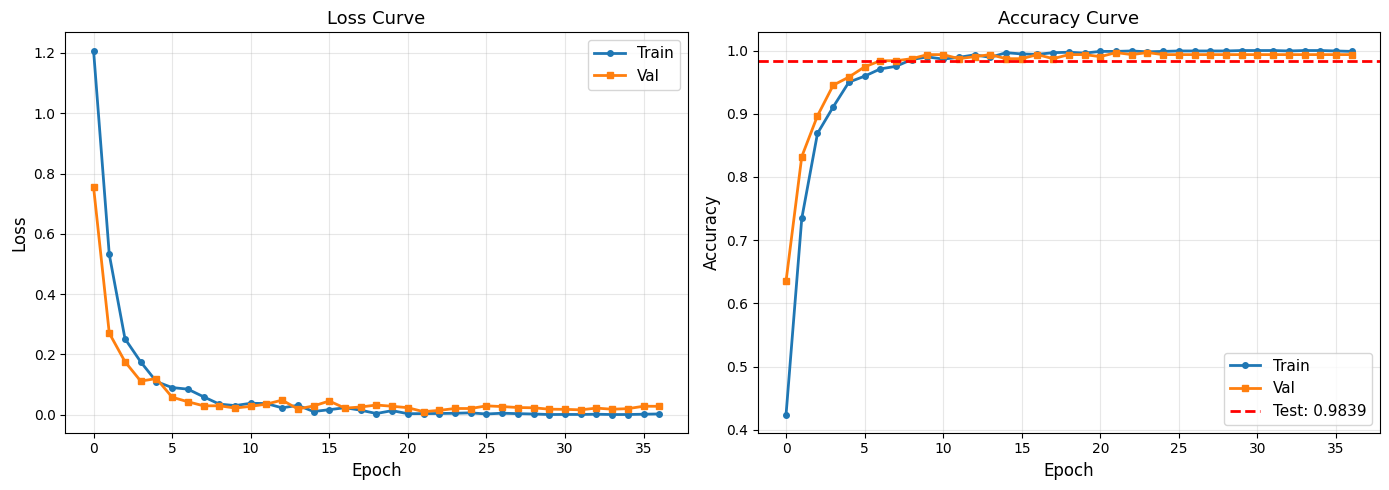

✓ Saved curves to /gpfs/gibbs/project/papademetris/jg3279/USFM/week9/ablation_F_full_finetune/curves.png


In [10]:
checkpoint = torch.load(best_model_path, map_location=device)
model_to_load = model.module if isinstance(model, nn.DataParallel) else model
model_to_load.load_state_dict(checkpoint['model_state_dict'])

test_loss, test_acc = validate(model, test_loader, criterion, device)
print(f'\n📊 Test Results:')
print(f'✓ Test Loss:     {test_loss:.4f}')
print(f'✓ Test Accuracy: {test_acc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train', marker='o', markersize=4, linewidth=2)
axes[0].plot(val_losses,   label='Val',   marker='s', markersize=4, linewidth=2)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Loss Curve', fontsize=13)

axes[1].plot(train_accs, label='Train', marker='o', markersize=4, linewidth=2)
axes[1].plot(val_accs,   label='Val',   marker='s', markersize=4, linewidth=2)
axes[1].axhline(y=test_acc, color='r', linestyle='--', label=f'Test: {test_acc:.4f}', linewidth=2)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Accuracy Curve', fontsize=13)

plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'curves.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Saved curves to {OUTPUT_PATH / "curves.png"}')

In [11]:
def extract_embeddings(model, dataloader, device):
    model.eval()
    actual_model = model.module if isinstance(model, nn.DataParallel) else model
    embeddings_list = []
    organs_list     = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Extracting', leave=False):
            images     = batch['image'].to(device)
            embeddings = actual_model.extract_features(images)
            embeddings_list.append(embeddings.cpu().numpy())
            organs_list.extend(batch['organ_name'])
    
    return np.vstack(embeddings_list), np.array(organs_list)


print('Extracting embeddings...')
for split_name, loader in [('train', train_loader), ('val', val_loader), ('test', test_loader)]:
    embeddings, organs = extract_embeddings(model, loader, device)
    np.save(OUTPUT_PATH / f'embeddings_{split_name}.npy', embeddings)
    np.save(OUTPUT_PATH / f'organs_{split_name}.npy',     organs)
    print(f'✓ {split_name}: {embeddings.shape}')

print(f'\n✅ Done!')
print(f'Results saved to: {OUTPUT_PATH}')

Extracting embeddings...


✓ train: (1480, 768)


✓ val: (310, 768)


✓ test: (310, 768)

✅ Done!
Results saved to: /gpfs/gibbs/project/papademetris/jg3279/USFM/week9/ablation_F_full_finetune
